In [18]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


store_path = "/mnt/data/store.csv"
employee_path = "/mnt/data/employee.csv"
product_path = "/mnt/data/product.csv"
sales_path = "/mnt/data/sales_performance.csv"

store_df = pd.read_csv("/Users/alishanmeru/Downloads/data/store.csv")
employee_df = pd.read_csv("/Users/alishanmeru/Downloads/data/employee.csv")
product_df = pd.read_csv("/Users/alishanmeru/Downloads/data/product.csv")
sales_df = pd.read_csv("/Users/alishanmeru/Downloads/data/sales_performance.csv")

print(store_df.shape, employee_df.shape, product_df.shape, sales_df.shape)
store_df.head()

(11, 4) (100, 4) (42, 3) (20000, 6)


,Store_ID,Store_Name,City,Opening_Year
0,1,Store_1,Edmonton,2013
1,2,Store_2,Vancouver,1997
2,3,Store_3,Vancouver,2011
3,4,Store_4,Vancouver,2018
4,5,Store_5,Edmonton,2001


In [19]:
# Enforce schema data types
# Store
store_df["Store_ID"] = pd.to_numeric(store_df["Store_ID"], errors="coerce").astype("Int64")
store_df["Opening_Year"] = pd.to_numeric(store_df["Opening_Year"], errors="coerce").astype("Int64")

# Employee (DOB/DOJ can be ignored in checks, but IDs still matter)
employee_df["Employee_ID"] = pd.to_numeric(employee_df["Employee_ID"], errors="coerce").astype("Int64")
employee_df["Store_ID"] = pd.to_numeric(employee_df["Store_ID"], errors="coerce").astype("Int64")

# Product
product_df["Product_ID"] = pd.to_numeric(product_df["Product_ID"], errors="coerce").astype("Int64")
product_df["Base_Price"] = pd.to_numeric(product_df["Base_Price"], errors="coerce")

# Sales_Performance
sales_df["Employee_ID"] = pd.to_numeric(sales_df["Employee_ID"], errors="coerce").astype("Int64")
sales_df["Product_ID"] = pd.to_numeric(sales_df["Product_ID"], errors="coerce").astype("Int64")
sales_df["Units_Sold"] = pd.to_numeric(sales_df["Units_Sold"], errors="coerce").astype("Int64")
sales_df["Revenue"] = pd.to_numeric(sales_df["Revenue"], errors="coerce")
sales_df["Effort_Hours"] = pd.to_numeric(sales_df["Effort_Hours"], errors="coerce")

sales_df["Sale_Date"] = pd.to_datetime(sales_df["Sale_Date"], errors="coerce")

In [20]:
employee_df.dtypes

Employee_ID    Int64
DOB              str
DOJ              str
Store_ID       Int64
dtype: object

In [21]:
product_df.dtypes

Product_ID      Int64
Category          str
Base_Price    float64
dtype: object

In [22]:
sales_df.dtypes

Employee_ID              Int64
Product_ID               Int64
Sale_Date       datetime64[us]
Units_Sold               Int64
Revenue                float64
Effort_Hours           float64
dtype: object

In [23]:
# Connect to DuckDB
con = duckdb.connect(database=":memory:")

In [24]:
# Create the staging table
con.register("store_df", store_df)
con.register("employee_df", employee_df)
con.register("product_df", product_df)
con.register("sales_df", sales_df)

con.execute("CREATE TABLE stg_store AS SELECT * FROM store_df;")
con.execute("CREATE TABLE stg_employee AS SELECT * FROM employee_df;")
con.execute("CREATE TABLE stg_product AS SELECT * FROM product_df;")
con.execute("CREATE TABLE stg_sales_performance AS SELECT * FROM sales_df;")

In [25]:
# Create the final schema 

con.execute("""
CREATE TABLE Store (
 Store_ID INT PRIMARY KEY,
 Store_Name VARCHAR(50),
 City VARCHAR(50),
 Opening_Year INT
);
""")

# Had to chnage DOB and DOJ to VARCHAR
con.execute("""
CREATE TABLE Employee (
 Employee_ID INT PRIMARY KEY,
 DOB VARCHAR(50),
 DOJ VARCHAR(50),
 Store_ID INT,
 FOREIGN KEY (Store_ID) REFERENCES Store(Store_ID)
);
""")

con.execute("""
CREATE TABLE Product (
 Product_ID INT PRIMARY KEY,
 Category VARCHAR(50),
 Base_Price FLOAT
);
""")

con.execute("""
CREATE TABLE Sales_Performance (
 Employee_ID INT,
 Product_ID INT,
 Sale_Date DATE,
 Units_Sold INT,
 Revenue FLOAT,
 Effort_Hours FLOAT,
 FOREIGN KEY (Employee_ID) REFERENCES Employee(Employee_ID),
 FOREIGN KEY (Product_ID) REFERENCES Product(Product_ID)
);
""")

In [26]:
# Primary key uniqueness (includes invalid/nulls in count)

con.execute("""
SELECT
  (SELECT COUNT(*) - COUNT(DISTINCT Store_ID) FROM stg_store) AS store_pk_dups,
  (SELECT COUNT(*) - COUNT(DISTINCT Employee_ID) FROM stg_employee) AS employee_pk_dups,
  (SELECT COUNT(*) - COUNT(DISTINCT Product_ID) FROM stg_product) AS product_pk_dups
""").df()

,store_pk_dups,employee_pk_dups,product_pk_dups
0,0,1,1


In [27]:
# Foreign key validity employee and store_id
con.execute("""
SELECT
  SUM(CASE WHEN s.Store_ID IS NULL THEN 1 ELSE 0 END) AS employee_store_fk_invalid
FROM stg_employee e
LEFT JOIN stg_store s ON e.Store_ID = s.Store_ID
""").df()

,employee_store_fk_invalid
0,1.0


In [28]:
# Foreign key validity sales performance and employee_id
con.execute("""
SELECT
  SUM(CASE WHEN e.Employee_ID IS NULL THEN 1 ELSE 0 END) AS sales_employee_fk_invalid
FROM stg_sales_performance sp
LEFT JOIN stg_employee e ON sp.Employee_ID = e.Employee_ID
""").df()

,sales_employee_fk_invalid
0,194.0


In [29]:
# Foreign key validity sales performance and product_id
con.execute("""
SELECT
  SUM(CASE WHEN p.Product_ID IS NULL THEN 1 ELSE 0 END) AS sales_product_fk_invalid
FROM stg_sales_performance sp
LEFT JOIN stg_product p ON sp.Product_ID = p.Product_ID
""").df()

,sales_product_fk_invalid
0,0.0


In [30]:
# Validating according to criteria set in assignment doc
con.execute("""
SELECT
  SUM(CASE WHEN Opening_Year IS NULL OR Opening_Year <= 1900 THEN 1 ELSE 0 END) AS bad_opening_year,
  (SELECT SUM(CASE WHEN Base_Price IS NULL OR Base_Price > 500 THEN 1 ELSE 0 END) FROM stg_product) AS bad_base_price,
  (SELECT SUM(CASE WHEN Revenue IS NULL OR Revenue <= 0 OR Revenue > 600 THEN 1 ELSE 0 END) FROM stg_sales_performance) AS bad_revenue,
  (SELECT SUM(CASE WHEN Units_Sold IS NULL OR Units_Sold < 1 THEN 1 ELSE 0 END) FROM stg_sales_performance) AS bad_units_sold,
  (SELECT SUM(CASE WHEN Effort_Hours IS NULL OR Effort_Hours < 0 THEN 1 ELSE 0 END) FROM stg_sales_performance) AS bad_effort_hours
FROM stg_store
""").df()

,bad_opening_year,bad_base_price,bad_revenue,bad_units_sold,bad_effort_hours
0,1.0,1.0,3.0,0.0,1.0


In [31]:
# Cleaning store and product tables
con.execute("""
CREATE TABLE clean_store AS
SELECT *
FROM stg_store
WHERE Opening_Year IS NOT NULL AND Opening_Year > 1900
  AND Store_ID IS NOT NULL;
""")

con.execute("""
CREATE TABLE clean_product AS
SELECT *
FROM stg_product
WHERE Base_Price IS NOT NULL AND Base_Price <= 500
  AND Product_ID IS NOT NULL;
""")

In [32]:
# Clean employee table
con.execute("""
CREATE TABLE clean_employee AS
SELECT e.*
FROM stg_employee e
JOIN clean_store s ON e.Store_ID = s.Store_ID
WHERE e.Employee_ID IS NOT NULL;
""")

In [33]:
# Clean Sales_Performance table
con.execute("""
CREATE TABLE clean_sales_performance AS
SELECT sp.*
FROM stg_sales_performance sp
JOIN clean_employee e ON sp.Employee_ID = e.Employee_ID
JOIN clean_product p ON sp.Product_ID = p.Product_ID
WHERE sp.Units_Sold IS NOT NULL AND sp.Units_Sold >= 1
  AND sp.Effort_Hours IS NOT NULL AND sp.Effort_Hours >= 0
  AND sp.Revenue IS NOT NULL AND sp.Revenue > 0 AND sp.Revenue <= 600
  AND sp.Sale_Date IS NOT NULL;
""")

In [34]:

con.execute("""
SELECT
  (SELECT COUNT(*) FROM stg_store) AS stg_store_rows,
  (SELECT COUNT(*) FROM clean_store) AS clean_store_rows,
  (SELECT COUNT(*) FROM stg_employee) AS stg_employee_rows,
  (SELECT COUNT(*) FROM clean_employee) AS clean_employee_rows,
  (SELECT COUNT(*) FROM stg_product) AS stg_product_rows,
  (SELECT COUNT(*) FROM clean_product) AS clean_product_rows,
  (SELECT COUNT(*) FROM stg_sales_performance) AS stg_sales_rows,
  (SELECT COUNT(*) FROM clean_sales_performance) AS clean_sales_rows
""").df()

,stg_store_rows,clean_store_rows,stg_employee_rows,clean_employee_rows,stg_product_rows,clean_product_rows,stg_sales_rows,clean_sales_rows
0,11,10,100,98,42,40,20000,19603


In [35]:
# Load only the clean data into the final constrained tables
con.execute("INSERT INTO Store SELECT * FROM clean_store;")
con.execute("INSERT INTO Product SELECT * FROM clean_product;")
con.execute("INSERT INTO Employee SELECT * FROM clean_employee;")
con.execute("INSERT INTO Sales_Performance SELECT * FROM clean_sales_performance;")

In [36]:
# transform into an aggregated dataset for mining
mining_df = con.execute("""
SELECT
  sp.Employee_ID,
  e.Store_ID,
  s.Store_Name,
  s.City,
  sp.Product_ID,
  p.Category,
  p.Base_Price,
  sp.Sale_Date,
  sp.Units_Sold,
  sp.Revenue,
  sp.Effort_Hours,
  (sp.Revenue / NULLIF(sp.Effort_Hours, 0)) AS Revenue_per_Hour
FROM Sales_Performance sp
JOIN Employee e ON sp.Employee_ID = e.Employee_ID
JOIN Store s ON e.Store_ID = s.Store_ID
JOIN Product p ON sp.Product_ID = p.Product_ID
""").df()

mining_df.head()

,Employee_ID,Store_ID,Store_Name,City,Product_ID,Category,Base_Price,Sale_Date,Units_Sold,Revenue,Effort_Hours,Revenue_per_Hour
0,1051,9,Store_9,Edmonton,204,Home,271.329987,2024-02-27,7,282.750000,11.63,24.312124
1,1092,4,Store_4,Vancouver,231,Clothing,153.160004,2024-01-07,9,276.500000,7.35,37.619049
2,1014,5,Store_5,Edmonton,223,Clothing,275.709991,2024-04-22,3,219.289993,5.91,37.104908
3,1071,4,Store_4,Vancouver,218,Electronics,290.420013,2024-06-14,8,344.519989,11.03,31.234814
4,1060,7,Store_7,Vancouver,211,Electronics,101.949997,2024-05-23,6,298.220001,10.90,27.359634


In [37]:
# Statistic summary
mining_df[["Revenue","Effort_Hours","Units_Sold","Base_Price", "Revenue_per_Hour"]].describe()

,Revenue,Effort_Hours,Units_Sold,Base_Price,Revenue_per_Hour
count,19603.000000,19603.000000,19603.000000,19603.000000,19603.000000
mean,228.583405,6.497331,5.007193,171.094482,38.829151
std,97.403923,3.176319,2.584201,90.190956,13.390992
min,28.030001,0.950000,1.000000,16.590000,20.534708
25%,150.485001,3.760000,3.000000,102.180000,30.688222
50%,223.539993,6.500000,5.000000,153.160004,35.837814
75%,299.875000,9.250000,7.000000,263.820007,42.393538
max,528.080017,12.000000,9.000000,296.750000,151.556610


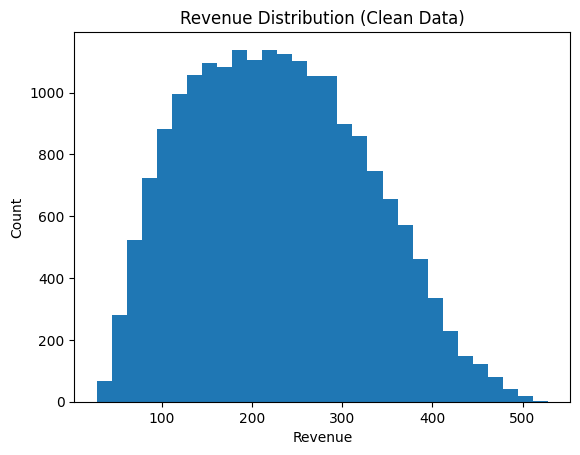

In [38]:
# plot revenue distribution
plt.figure()
plt.hist(mining_df["Revenue"], bins=30)
plt.title("Revenue Distribution (Clean Data)")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

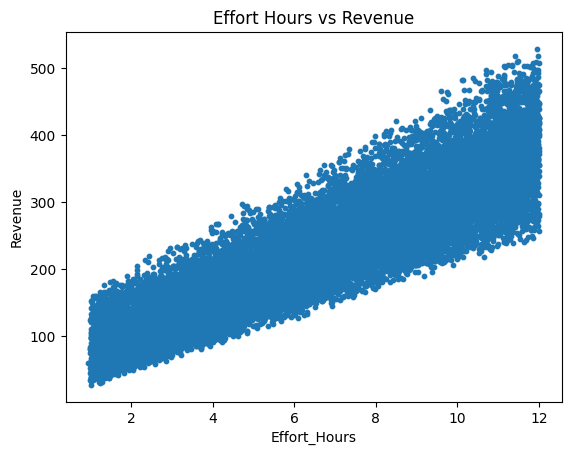

In [39]:
# plot effort hours vs revenue
plt.figure()
plt.scatter(mining_df["Effort_Hours"], mining_df["Revenue"], s=10)
plt.title("Effort Hours vs Revenue")
plt.xlabel("Effort_Hours")
plt.ylabel("Revenue")
plt.show()

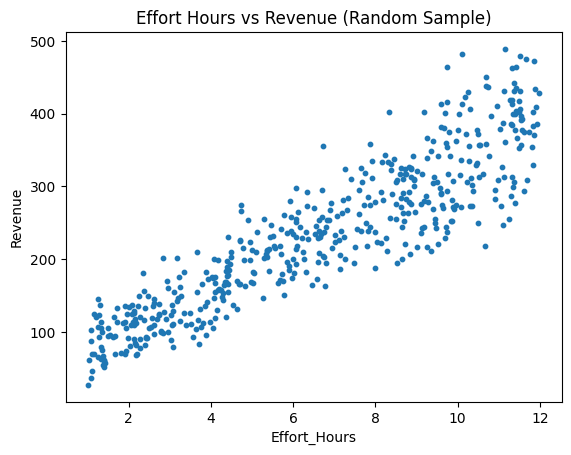

In [40]:
# Plotting effort hours vs revenue using smaller and random samples
sample_df = mining_df.sample(n=500, random_state=42)

plt.figure()
plt.scatter(sample_df["Effort_Hours"], sample_df["Revenue"], s=10)
plt.title("Effort Hours vs Revenue (Random Sample)")
plt.xlabel("Effort_Hours")
plt.ylabel("Revenue")
plt.show()

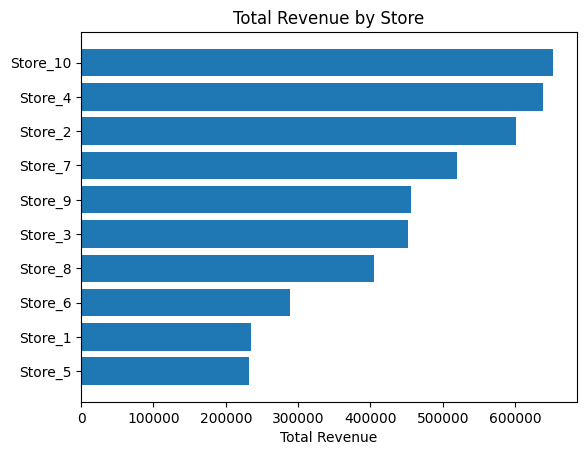

In [51]:
# Plot top stores ranking by total revenue
store_summary_sorted = store_summary.sort_values("Total_Revenue")

plt.figure()
plt.barh(store_summary_sorted["Store_Name"], store_summary_sorted["Total_Revenue"])
plt.title("Total Revenue by Store")
plt.xlabel("Total Revenue")
plt.show()

In [44]:
# Building the regression model and using it to predict revenue at 10 hours
X = mining_df[["Effort_Hours"]]
y = mining_df["Revenue"]

model = LinearRegression()
model.fit(X, y)

predict_10 = model.predict(pd.DataFrame({"Effort_Hours":[10]}))[0]

print("Regression model:")
print("slope:", model.coef_[0])
print("intercept:", model.intercept_)
print("Predicted Revenue at 10 hours:", predict_10)

Regression model:
slope: 27.408285
intercept: 50.5027
Predicted Revenue at 10 hours: 324.5855522155762


In [58]:
mining_1007 = mining_df[mining_df["Employee_ID"] == 1007]

X_1007 = mining_1007[["Effort_Hours"]]
y_1007 = mining_1007["Revenue"]

model_1007 = LinearRegression()
model_1007.fit(X_1007, y_1007)

pred_1007_10 = model_1007.predict(pd.DataFrame({"Effort_Hours":[10]}))[0]

print("Employee 1007 model:")
print("rows:", len(mining_1007))
print("slope:", model_1007.coef_[0])
print("intercept:", model_1007.intercept_)
print("Predicted Revenue at 10 hours:", pred_1007_10)

Employee 1007 model:
rows: 205
slope: 26.340513
intercept: 57.308365
Predicted Revenue at 10 hours: 320.71349716186523


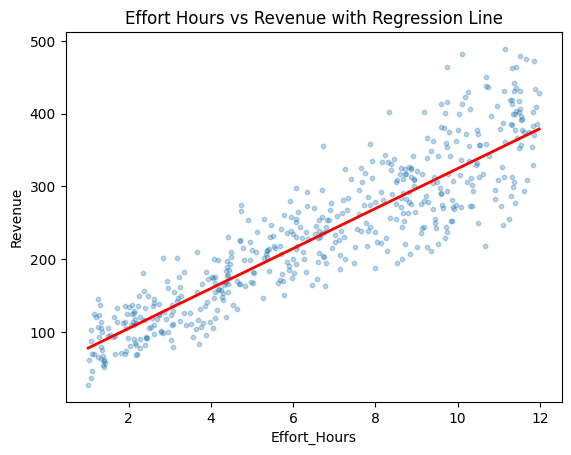

In [57]:
import numpy as np

plt.figure()

plt.scatter(sample_df["Effort_Hours"], sample_df["Revenue"], s=10, alpha=0.3)

# Create x values across the range
x_vals = np.linspace(
    sample_df["Effort_Hours"].min(),
    sample_df["Effort_Hours"].max(),
    100
)

y_vals = model.intercept_ + model.coef_[0] * x_vals

# Plot regression line
plt.plot(x_vals, y_vals, color="red", linewidth=2)

plt.title("Effort Hours vs Revenue with Regression Line")
plt.xlabel("Effort_Hours")
plt.ylabel("Revenue")
plt.show()